# PyTorch FashionMNIST Classification

## Phase 1 — Environment Setup

In [10]:
import sys
import torch
import torchvision
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

Python version: 3.10.11
PyTorch version: 2.13.0
TorchVision version: 0.28.0
CUDA available: False
MPS available: True


## Phase 2 — Run the Full Pipeline

In [ ]:
import sys
import os

PRACTICE_DIR = "/Users/ticoder-coder/Documents/DEEP_LEARNING/LAB&PRACTICE/total_practice/practice_1"
PARENT_DIR  = "/Users/ticoder-coder/Documents/DEEP_LEARNING/LAB&PRACTICE/total_practice"

if PARENT_DIR not in sys.path:
    sys.path.insert(0, PARENT_DIR)

os.chdir(PRACTICE_DIR)
print(f"Working directory: {os.getcwd()}")

from processing_own_phase.main import run_full_pipeline

summary = run_full_pipeline(quick_test=False)
summary

Working directory: /Users/ticoder-coder/Documents/DEEP_LEARNING/LAB&PRACTICE/total_practice/practice_1

FashionMNIST Classification Pipeline
ENVIRONMENT SUMMARY
Python version     : 3.10.11
PyTorch version    : 2.13.0
CUDA available     : False
MPS available      : True
Using device       : mps

[Phase 2] Loading FashionMNIST dataset...
  Train size: 54001
  Val size:   5999
  Test size:  10000
  Sample shape: (1, 28, 28) dtype: torch.float32 min: 0.000 max: 1.000 label: Ankle boot

[EDA] Saving data samples and class distribution...

[Phase 3] Building model and running sanity checks...
  Architecture: [128] | Dropout: 0.0
  Parameters: 101,770
  Forward shape: (64, 10)
  Loss is finite: True (loss=2.3187)
  Gradients populated: True
  Params changed after step: True

[Phase 4-5] Running controlled experiments...
EXPERIMENT: E0_baseline
Description: Baseline: 1 hidden layer, SGD, lr=0.01
Architecture: [128] | Dropout: 0.0 | Optimizer: SGD | LR: 0.01 | Batch: 64 | Epochs: 10
Epoch 01/1

{'device': 'mps',
 'config': {'seed': 42,
  'batch_size': 64,
  'num_workers': 0,
  'train_split_ratio': 0.9,
  'hidden_dims': [128],
  'dropout': 0.0,
  'epochs': 10,
  'learning_rate': 0.01,
  'optimizer': 'SGD',
  'momentum': 0.9,
  'weight_decay': 0.0,
  'data_dir': '/Users/ticoder-coder/Documents/DEEP_LEARNING/LAB&PRACTICE/total_practice/practice_1/data',
  'output_dir': '/Users/ticoder-coder/Documents/DEEP_LEARNING/LAB&PRACTICE/total_practice/practice_1/outputs',
  'model_save_path': '/Users/ticoder-coder/Documents/DEEP_LEARNING/LAB&PRACTICE/total_practice/practice_1/outputs/best_model.pth',
  'experiment_results_csv': '/Users/ticoder-coder/Documents/DEEP_LEARNING/LAB&PRACTICE/total_practice/practice_1/save_log_agent_process_each_phase/experiment_results.csv'},
 'best_experiment': 'E5_adam',
 'best_val_acc': 0.8858143023837306,
 'best_val_loss': 0.31092545764210583,
 'best_epoch': 10,
 'test_accuracy': 0.8817,
 'test_loss': 0.32857485156059263,
 'per_class_accuracy': {0: 0.796,
 

## Phase 3 — Visualizations

--- data_samples.png ---


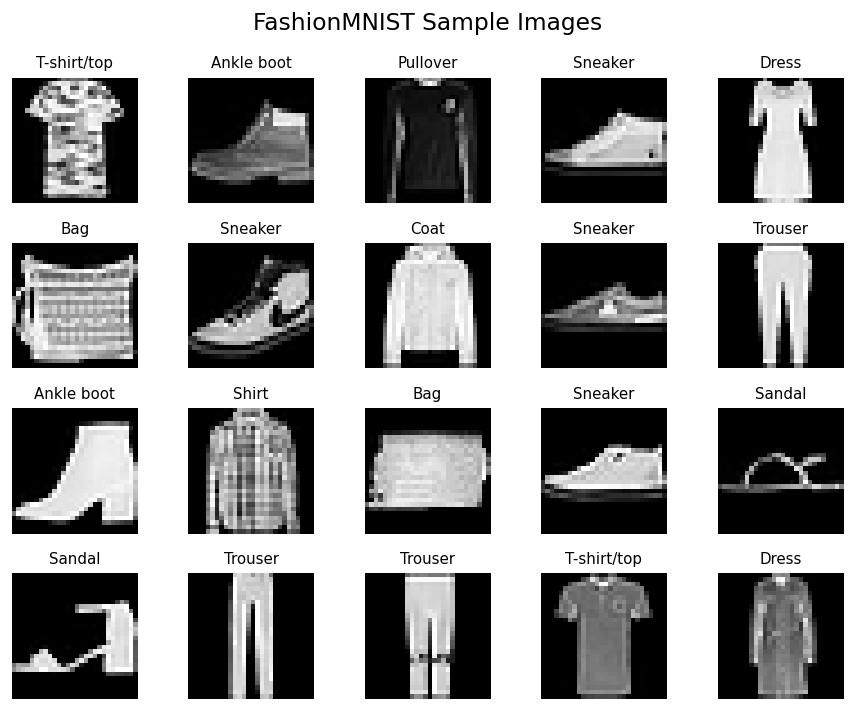

--- class_distribution.png ---


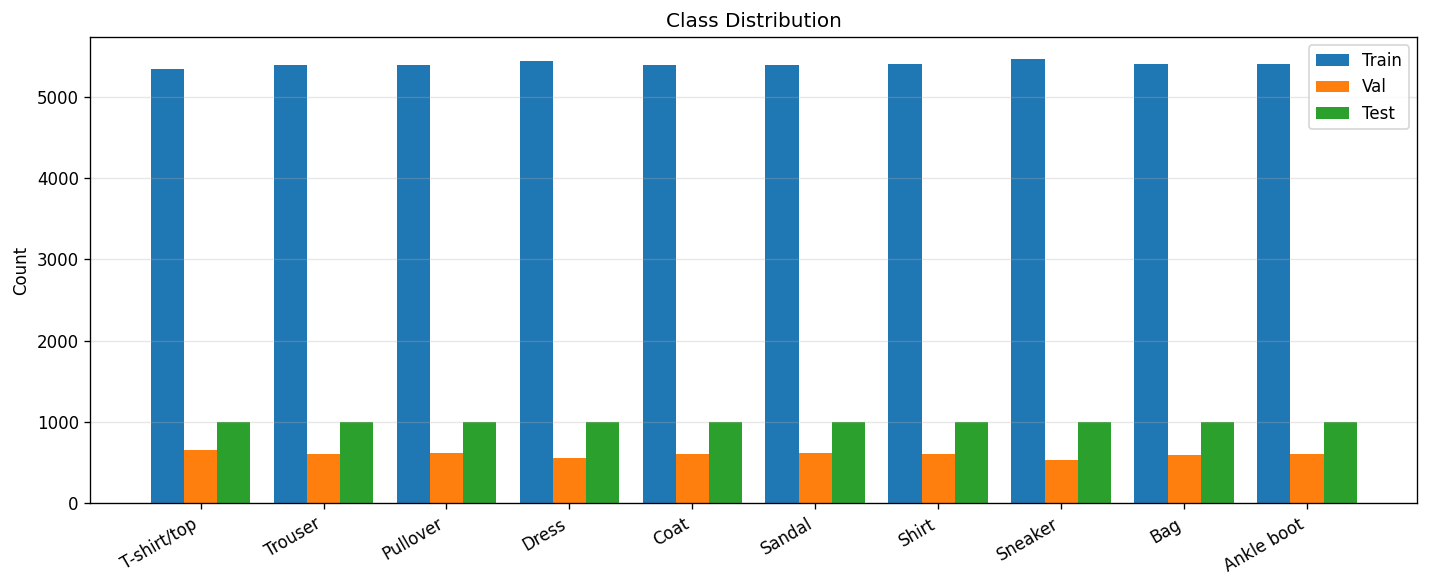

--- loss_curve.png ---


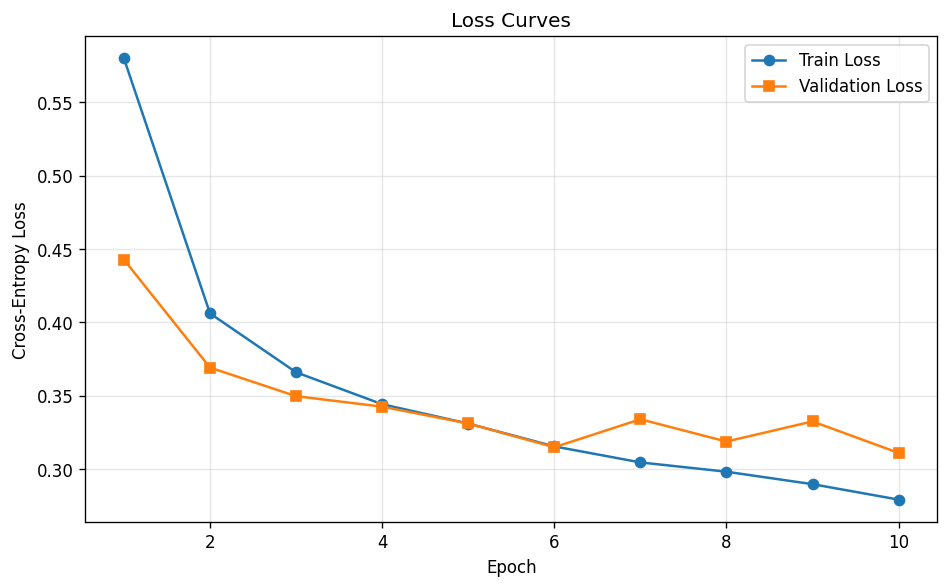

--- accuracy_curve.png ---


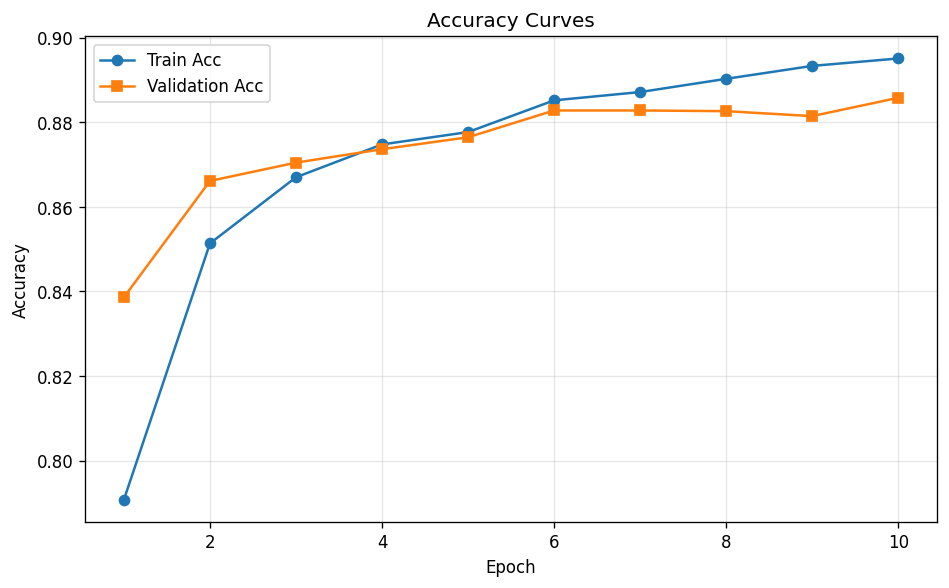

--- experiment_comparison.png ---


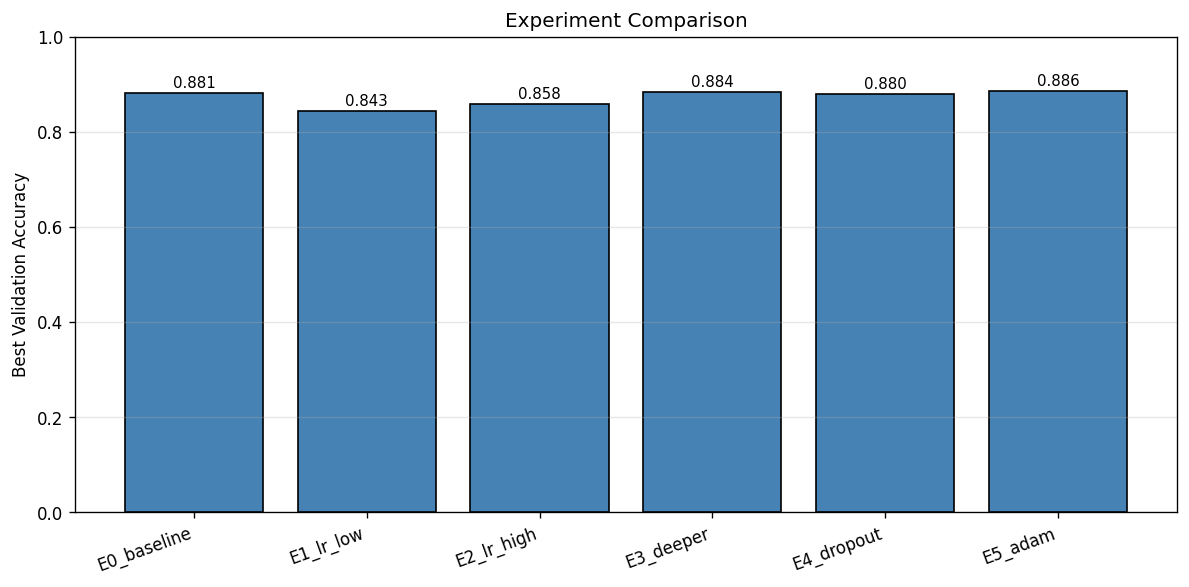

--- confusion_matrix.png ---


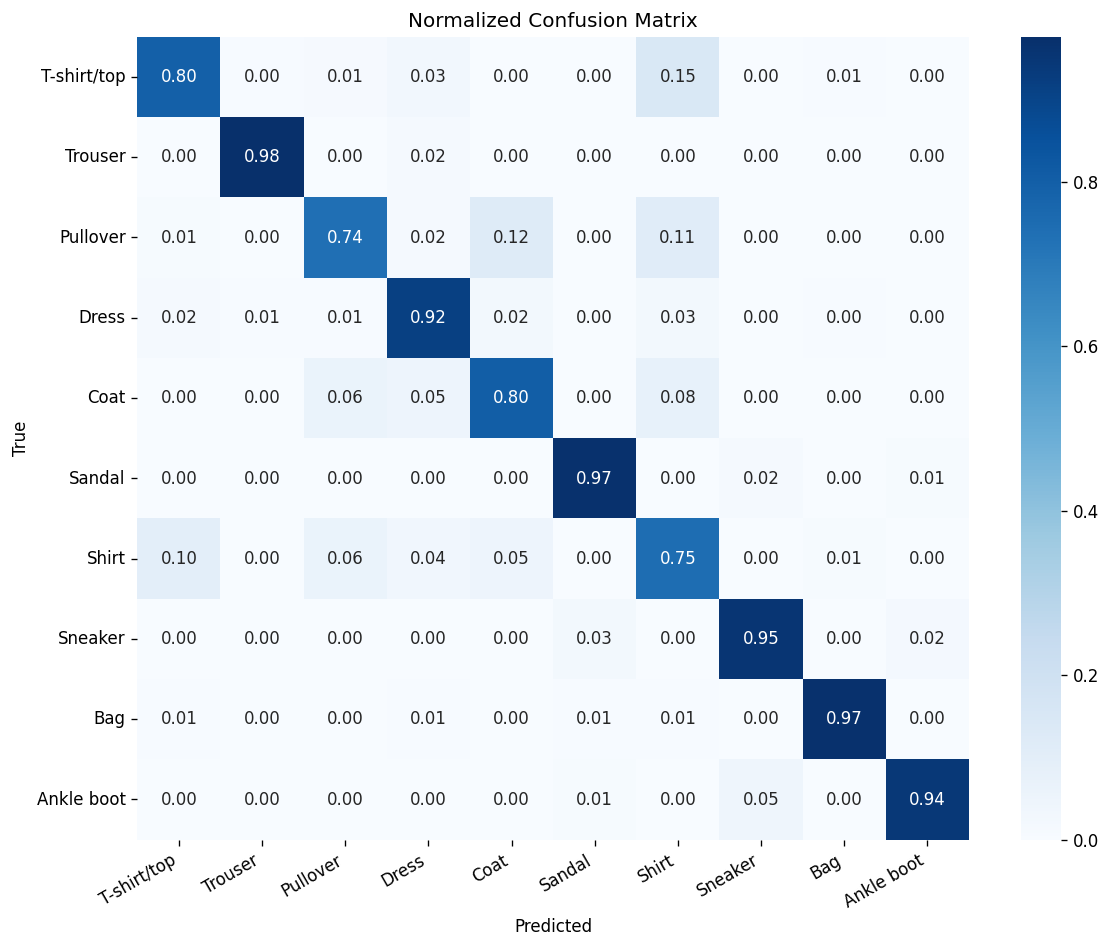

--- predictions_grid.png ---


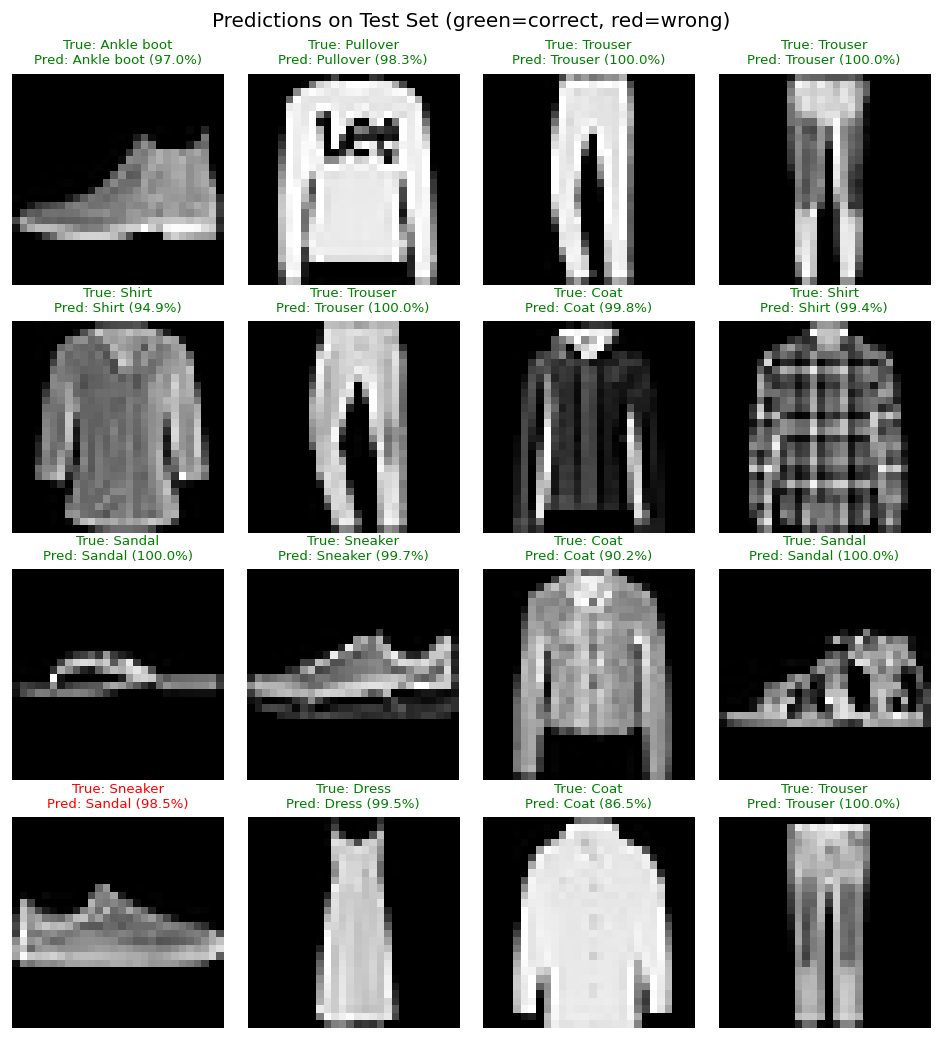

In [12]:
from IPython.display import Image, display
import os

PRACTICE_DIR = "/Users/ticoder-coder/Documents/DEEP_LEARNING/LAB&PRACTICE/total_practice/practice_1"
OUTPUT_DIR  = os.path.join(PRACTICE_DIR, "outputs")

PLOT_FILES = [
    "data_samples.png",
    "class_distribution.png",
    "loss_curve.png",
    "accuracy_curve.png",
    "experiment_comparison.png",
    "confusion_matrix.png",
    "predictions_grid.png",
]

for fname in PLOT_FILES:
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(path):
        print(f"--- {fname} ---")
        display(Image(filename=path))
    else:
        print(f"Missing: {path}")

## Phase 4 — Experiment Results Table

In [13]:
import pandas as pd
import os

PRACTICE_DIR = "/Users/ticoder-coder/Documents/DEEP_LEARNING/LAB&PRACTICE/total_practice/practice_1"
CSV_PATH = os.path.join(PRACTICE_DIR, "save_log_agent_process_each_phase", "experiment_results.csv")

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    cols = ["exp_id", "hidden_dims", "optimizer", "learning_rate",
            "dropout", "best_val_acc", "best_epoch", "n_parameters", "total_time_seconds"]
    display(df[cols])
else:
    print(f"CSV not found: {CSV_PATH}")

,exp_id,hidden_dims,optimizer,learning_rate,dropout,best_val_acc,best_epoch,n_parameters,total_time_seconds
0,E0_baseline,[128],SGD,0.010,0.0,0.881314,10,101770,43.742113
1,E1_lr_low,[128],SGD,0.001,0.0,0.843141,10,101770,39.312902
2,E2_lr_high,[128],SGD,0.100,0.0,0.858476,7,101770,41.664347
3,E3_deeper,"[256, 128]",SGD,0.010,0.0,0.884481,10,235146,54.948663
4,E4_dropout,"[256, 128]",SGD,0.010,0.2,0.880147,8,235146,53.558780
5,E5_adam,"[256, 128]",Adam,0.001,0.2,0.885814,10,235146,67.070869
